# Stage 7 — Feature Category Detection

Map each review to one or more **feature categories** using a keyword taxonomy.

**Categories defined:**
- Performance, Graphics, Story, Gameplay, Combat, Audio, NPC/AI, Open World, UI/UX, Bugs

**Output:** `data/processed/categorized_reviews.csv`

## 1. Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='darkgrid')

df = pd.read_csv('../data/processed/preprocessed_reviews.csv')
df = df[df['clean_review'].notna() & (df['clean_review'].str.strip() != '')].copy()
df.reset_index(drop=True, inplace=True)

print(f'Loaded {len(df):,} reviews')
print(df.columns.tolist())

Loaded 282,547 reviews
['recommendationid', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'hidden_in_steam_china', 'created', 'updated', 'steamid', 'num_games_owned', 'num_reviews', 'playtime_forever', 'playtime_last_two_weeks', 'playtime_at_review', 'last_played', 'review_length', 'clean_review']


## 2. Feature Category Taxonomy

In [2]:
FEATURE_TAXONOMY = {
    'Performance': [
        'fps', 'frame rate', 'framerate', 'stutter', 'stuttering', 'lag', 'lagging',
        'optimization', 'optimized', 'performance', 'loading', 'load time', 'slow',
        'freezing', 'freeze', 'latency', 'frame drop', 'frame drops', 'vram',
        'cpu', 'gpu', 'memory', 'ram', 'resolution', 'settings', 'graphics settings',
        'ultra', 'dlss', 'fsr', 'ray tracing performance', 'raytracing performance',
        'benchmark', 'smooth', 'smoothly', 'choppy'
    ],
    'Graphics': [
        'graphics', 'visual', 'visuals', 'beautiful', 'stunning', 'gorgeous',
        'ray tracing', 'raytracing', 'lighting', 'texture', 'textures',
        'art style', 'art direction', 'aesthetic', 'look', 'looks', 'design',
        'neon', 'cyberpunk aesthetic', 'atmosphere', 'atmospheric', 'immersive',
        'detail', 'detailed', 'city', 'night city', 'environment', 'render',
        'animation', 'character model', 'shadow', 'ambient', 'bloom'
    ],
    'Story': [
        'story', 'narrative', 'plot', 'writing', 'written', 'dialogue',
        'character', 'characters', 'protagonist', 'ending', 'endings',
        'main quest', 'main story', 'lore', 'world building', 'worldbuilding',
        'johnny silverhand', 'silverhand', 'keanu', 'choice', 'choices',
        'decision', 'decisions', 'branching', 'cutscene', 'cutscenes',
        'voice acting', 'voice actor', 'emotion', 'emotional', 'immersion'
    ],
    'Gameplay': [
        'gameplay', 'mechanic', 'mechanics', 'fun', 'enjoyable', 'boring',
        'level design', 'mission', 'missions', 'quest', 'quests', 'side quest',
        'side quests', 'progression', 'skill', 'skills', 'skill tree',
        'ability', 'abilities', 'perk', 'perks', 'build', 'builds',
        'crafting', 'loot', 'looting', 'inventory', 'grind', 'grinding',
        'exploration', 'explore', 'sandbox', 'freedom', 'open world gameplay'
    ],
    'Combat': [
        'combat', 'fighting', 'fight', 'shooting', 'shooter', 'fps combat',
        'weapon', 'weapons', 'gun', 'guns', 'firearm', 'melee', 'sword',
        'katana', 'hack', 'hacking', 'netrunner', 'stealth', 'takedown',
        'enemy', 'enemies', 'ai combat', 'difficulty', 'easy', 'hard',
        'damage', 'health', 'armor', 'cyberware', 'implant', 'smart weapon'
    ],
    'Audio': [
        'music', 'soundtrack', 'sound', 'audio', 'sound design', 'sound effects',
        'sfx', 'ost', 'score', 'ambient sound', 'sound track', 'song', 'songs',
        'radio', 'volume', 'loud', 'quiet', 'hearing', 'ears', 'bass'
    ],
    'NPC_AI': [
        'npc', 'npcs', 'ai', 'police', 'cops', 'crowd', 'pedestrian', 'pedestrians',
        'civilian', 'civilians', 'behavior', 'behaviour', 'dumb', 'stupid',
        'smart', 'pathfinding', 'interaction', 'reactivity', 'react', 'responds',
        'companion', 'companions', 'vendor', 'gang', 'gangs'
    ],
    'Open_World': [
        'open world', 'world', 'map', 'city', 'night city', 'district',
        'street', 'streets', 'building', 'buildings', 'rooftop', 'alley',
        'fast travel', 'travel', 'drive', 'driving', 'vehicle', 'vehicles',
        'car', 'cars', 'traffic', 'bike', 'motorcycle', 'exploration',
        'discover', 'hidden', 'secret', 'size', 'scale', 'vast', 'density'
    ],
    'UI_UX': [
        'ui', 'ux', 'interface', 'menu', 'hud', 'minimap', 'map',
        'inventory ui', 'pause menu', 'settings menu', 'keybind', 'keybinds',
        'controller', 'mouse', 'keyboard', 'input', 'tutorial', 'tips',
        'font', 'readability', 'color', 'accessibility', 'subtitle', 'subtitles'
    ],
    'Bugs': [
        'bug', 'bugs', 'glitch', 'glitches', 'glitchy', 'broken', 'break',
        'crash', 'crashes', 'crashing', 'crash to desktop', 'ctd', 'softlock',
        'error', 'corrupted', 'save', 'saves', 'save file', 'patch', 'patches',
        'fix', 'fixed', 'update', 'updates', 'unfinished', 'unpolished',
        'janky', 'jank', 'clipping', 'clipped', 't-pose', 'floating',
        'disappear', 'missing', 'quest bug', 'mission bug'
    ]
}

print('Feature categories defined:')
for cat, kws in FEATURE_TAXONOMY.items():
    print(f'  {cat}: {len(kws)} keywords')

Feature categories defined:
  Performance: 35 keywords
  Graphics: 33 keywords
  Story: 31 keywords
  Gameplay: 34 keywords
  Combat: 31 keywords
  Audio: 20 keywords
  NPC_AI: 25 keywords
  Open_World: 31 keywords
  UI_UX: 24 keywords
  Bugs: 36 keywords


## 3. Category Detection Function

In [3]:
# Precompile regex patterns per category for speed
import re

PATTERNS = {}
for cat, keywords in FEATURE_TAXONOMY.items():
    # Sort by length desc so longer phrases match first
    sorted_kws = sorted(keywords, key=len, reverse=True)
    pattern = r'\b(' + '|'.join(re.escape(k) for k in sorted_kws) + r')\b'
    PATTERNS[cat] = re.compile(pattern, re.IGNORECASE)

def detect_categories(text):
    """Return a dict of {category: mention_count} for a review."""
    if not isinstance(text, str) or not text.strip():
        return {}
    result = {}
    for cat, pattern in PATTERNS.items():
        matches = pattern.findall(text)
        if matches:
            result[cat] = len(matches)
    return result

# Test
sample = "The fps drops are terrible and bugs make the game crash constantly."
print(f'Test: "{sample}"')
print(f'Categories: {detect_categories(sample)}')

Test: "The fps drops are terrible and bugs make the game crash constantly."
Categories: {'Performance': 1, 'Bugs': 2}


## 4. Apply Category Detection

In [4]:
# Use original review text (not preprocessed) for better phrase matching
print('Detecting feature categories for all reviews...')
df['category_hits'] = df['review'].apply(detect_categories)

# Add binary columns for each category
cats = list(FEATURE_TAXONOMY.keys())
for cat in cats:
    df[f'cat_{cat}'] = df['category_hits'].apply(lambda d: 1 if cat in d else 0)

# Primary category: whichever category has the most hits
def primary_category(d):
    if not d:
        return 'Other'
    return max(d, key=d.get)

df['primary_category'] = df['category_hits'].apply(primary_category)

# Reviews with at least one category match
df['has_category'] = df['category_hits'].apply(lambda d: len(d) > 0)

print(f'Reviews with at least one category match: {df["has_category"].sum():,} ({df["has_category"].mean()*100:.1f}%)')
print(f'\nPrimary category distribution:')
print(df['primary_category'].value_counts().to_string())

Detecting feature categories for all reviews...


Reviews with at least one category match: 172,767 (61.1%)

Primary category distribution:
primary_category
Other          109780
Bugs            46604
Story           38703
Gameplay        29899
Graphics        24285
Performance     12557
Open_World      10074
Combat           6800
NPC_AI           2422
Audio             827
UI_UX             596


## 5. Category Coverage Visualization

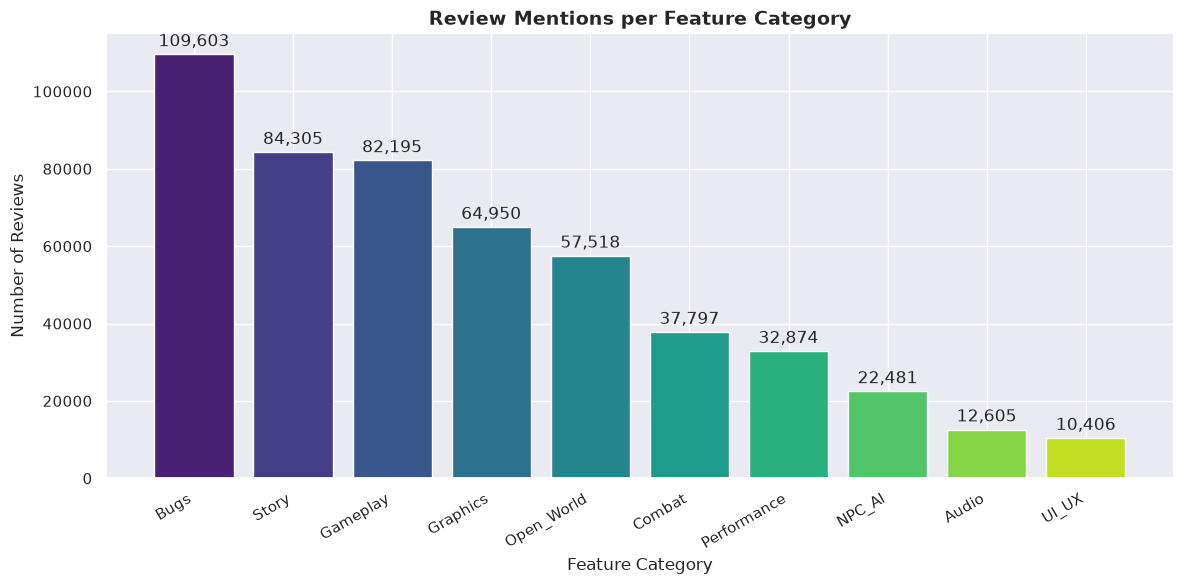

Category mention counts:
   Category  Mentions
       Bugs    109603
      Story     84305
   Gameplay     82195
   Graphics     64950
 Open_World     57518
     Combat     37797
Performance     32874
     NPC_AI     22481
      Audio     12605
      UI_UX     10406


In [5]:
# Count how many reviews mention each category (multi-label)
category_counts = {cat: df[f'cat_{cat}'].sum() for cat in cats}
cat_df = pd.DataFrame(list(category_counts.items()), columns=['Category', 'Mentions'])
cat_df = cat_df.sort_values('Mentions', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('viridis', len(cats))
bars = ax.bar(cat_df['Category'], cat_df['Mentions'], color=colors)
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Review Mentions per Feature Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Reviews')
ax.set_xlabel('Feature Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/category_mentions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Category mention counts:')
print(cat_df.to_string(index=False))

## 6. Save Results

In [6]:
# Save the full categorized dataframe
cols_to_save = [
    'review', 'voted_up', 'votes_up', 'votes_funny', 'playtime_forever',
    'created', 'clean_review', 'primary_category', 'has_category'
] + [f'cat_{cat}' for cat in cats]

# Only keep columns that exist
cols_to_save = [c for c in cols_to_save if c in df.columns]

df[cols_to_save].to_csv('../data/processed/categorized_reviews.csv', index=False)
print(f'Saved categorized_reviews.csv with {len(df):,} rows')

# Save taxonomy
with open('../data/processed/feature_taxonomy.json', 'w') as f:
    json.dump(FEATURE_TAXONOMY, f, indent=2)
print('Saved feature_taxonomy.json')

# Save category counts
cat_df.to_csv('../data/processed/category_counts.csv', index=False)
print('Saved category_counts.csv')

Saved categorized_reviews.csv with 282,547 rows
Saved feature_taxonomy.json
Saved category_counts.csv
